<a href="https://colab.research.google.com/github/Mayar215999/data-science-project/blob/main/Load_Documents_Using_LangChain_for_Different_Sources.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated time needed: 20 minutes

Imagine you are working as a data scientist at a consulting firm, and you've been tasked with analyzing documents from multiple clients. Each client provides their data in different formats: some in PDFs, others in Word documents, CSV files, or even HTML webpages. Manually loading and parsing each document type is not only time-consuming but also prone to errors. Your goal is to streamline this process, making it efficient and error-free.

To achieve this, you'll use LangChain’s powerful document loaders. These loaders allow you to read and convert various file formats into a unified document structure that can be easily processed. For example, you'll load client policy documents from text files, financial reports from PDFs, marketing strategies from Word documents, and product reviews from JSON files. By the end of this lab, you will have a robust pipeline that can handle any new file formats clients might send, saving you valuable time and effort.

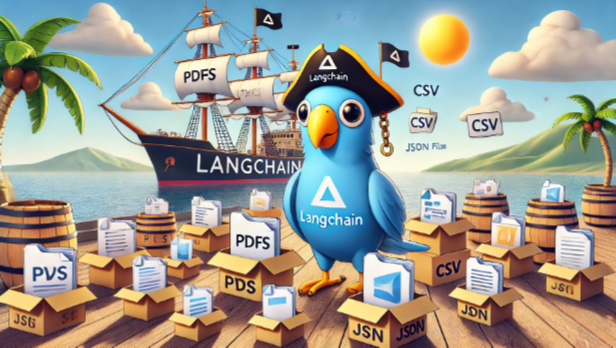

In this lab, you will explore how to use various loaders provided by LangChain to load and process data from different file formats. These loaders simplify the task of reading and converting files into a document format that can be processed downstream. By the end of this lab, you will be able to efficiently load text, PDF, Markdown, JSON, CSV, DOCX, and other file formats into a unified format, allowing for seamless data analysis and manipulation for LLM applications.

(Note: In this lab, we just introduced several commonly used file format loaders. LangChain provides more document loaders for various document formats here.)

Table of Contents
Objectives
Setup
Installing required libraries
Importing required libraries
Load from TXT files
Load from PDF files
Load from Markdown files
Load from JSON files
Load from CSV files
Load from URL/Webpage files
Load from WORD files
Load from Unstructured Files
Exercises

Exercise 1 - Try to use other PDF loaders
Exercise 2 - Load from Arxiv
Objectives
After completing this lab you will be able to:

Understand how to use TextLoader to load text files.
Learn how to load PDFs using PyPDFLoader and PyMuPDFLoader.
Use UnstructuredMarkdownLoader to load Markdown files.
Load JSON files with JSONLoader using jq schemas.
Process CSV files with CSVLoader and UnstructuredCSVLoader.
Load Webpage content using WebBaseLoader.
Load Word documents using Docx2txtLoader.
Utilize UnstructuredFileLoader for various file types.

Installing required libraries
The following required libraries are not preinstalled in the Skills Network Labs environment. You must run the following cell to install them:

Note: We are pinning the version here to specify the version. It's recommended that you do this as well. Even if the library is updated in the future, the installed library could still support this lab work.

This might take approximately 1 minute.

As we use %%capture to capture the installation, you won't see the output process. But after the installation completes, you will see a number beside the cell.

In [1]:
%%capture
#After executing the cell,please RESTART the kernel and run all the cells.
!pip install --user "langchain-community==0.2.1"
!pip install --user "pypdf==4.2.0"
!pip install --user "PyMuPDF==1.24.5"
!pip install --user "unstructured==0.14.8"
!pip install --user "markdown==3.6"
!pip install --user  "jq==1.7.0"
!pip install --user "pandas==2.2.2"
!pip install --user "docx2txt==0.8"
!pip install --user "requests==2.32.3"
!pip install --user "beautifulsoup4==4.12.3"
!pip install --user "nltk==3.8.0"

In [5]:
# You can also use this section to suppress warnings generated by your code:

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

from pprint import pprint
import json
from pathlib import Path
import nltk
!pip install "langchain-community==0.2.1"
!pip install "pypdf==4.2.0"
!pip install "PyMuPDF==1.24.5"
!pip install "unstructured==0.14.8"
!pip install "markdown==3.6"
!pip install "jq==1.7.0"
!pip install "pandas==2.2.2"
!pip install "docx2txt==0.8"
!pip install "requests==2.32.3"
!pip install "beautifulsoup4==4.12.3"
!pip install "nltk==3.8.0


nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

/bin/bash: line 1: pip install langchain-community==0.2.1: command not found
/bin/bash: line 1: pip install pypdf==4.2.0: command not found
/bin/bash: line 1: pip install PyMuPDF==1.24.5: command not found
/bin/bash: line 1: pip install unstructured==0.14.8: command not found
/bin/bash: line 1: pip install markdown==3.6: command not found
/bin/bash: line 1: pip install jq==1.7.0: command not found
/bin/bash: line 1: pip install pandas==2.2.2: command not found
/bin/bash: line 1: pip install docx2txt==0.8: command not found
/bin/bash: line 1: pip install requests==2.32.3: command not found
/bin/bash: line 1: pip install beautifulsoup4==4.12.3: command not found
/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

Load from TXT files
The TextLoader is a tool designed to load textual data from various sources.

It is the simplest loader, reading a file as text and placing all the content into a single document.

We have prepared a .txt file for you to load. First, we need to download it from a remote source.

We have prepared a .txt file for you to load. First, we need to download it from a remote source.

In [6]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Ec5f3KYU1CpbKRp1whFLZw/new-Policies.txt"

--2025-03-19 06:23:28--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Ec5f3KYU1CpbKRp1whFLZw/new-Policies.txt
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6363 (6.2K) [text/plain]
Saving to: ‘new-Policies.txt’

new-Policies.txt    100%[===================>]   6.21K  --.-KB/s    in 0s      

2025-03-19 06:23:29 (1.12 GB/s) - ‘new-Policies.txt’ saved [6363/6363]



Next, we will use the TextLoader class to load the file.

In [9]:
!pip install langchain


In [12]:
!pip install langchain-community -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.9/415.9 kB 25.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.2.43
    Uninstalling langchain-core-0.2.43:
      Successfully uninstalled langchain-core-0.2.43
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 0.2.4
    Uninstalling langchain-text-splitters-0.2.4:
      Successfully uninstalled langchain-text-splitters-0.2.4
  Attempting uninstall: langchain
    Found existing installation: langchain 0.2.17
    Uninstalling langchain-0.2.17:
      Successfully uninstalled langchain-0.2.17
  Attempting uninstall: langchain-community
    Found existing installation: langchain-community 0.2.1
    Uninstalling langchain-community-0.2.1:
      Successfully uninstalled langchain

In [13]:
from langchain.document_loaders import TextLoader # import TextLoader

loader = TextLoader("new-Policies.txt")
loader

In [14]:
data = loader.load()

In [15]:
data

[Document(metadata={'source': 'new-Policies.txt'}, page_content="1. Code of Conduct\n\nOur Code of Conduct establishes the core values and ethical standards that all members of our organization must adhere to. We are committed to fostering a workplace characterized by integrity, respect, and accountability.\n\nIntegrity: We commit to the highest ethical standards by being honest and transparent in all our dealings, whether with colleagues, clients, or the community. We protect sensitive information and avoid conflicts of interest.\n\nRespect: We value diversity and every individual's contribution. Discrimination, harassment, or any form of disrespect is not tolerated. We promote an inclusive environment where differences are respected, and everyone is treated with dignity.\n\nAccountability: We are responsible for our actions and decisions, complying with all relevant laws and regulations. We aim for continuous improvement and report any breaches of this code, supporting investigations

We can also use the pprint function to print the first 1000 characters of the page_content here.

In [16]:
pprint(data[0].page_content[:1000])

('1. Code of Conduct\n'
 '\n'
 'Our Code of Conduct establishes the core values and ethical standards that '
 'all members of our organization must adhere to. We are committed to '
 'fostering a workplace characterized by integrity, respect, and '
 'accountability.\n'
 '\n'
 'Integrity: We commit to the highest ethical standards by being honest and '
 'transparent in all our dealings, whether with colleagues, clients, or the '
 'community. We protect sensitive information and avoid conflicts of '
 'interest.\n'
 '\n'
 "Respect: We value diversity and every individual's contribution. "
 'Discrimination, harassment, or any form of disrespect is not tolerated. We '
 'promote an inclusive environment where differences are respected, and '
 'everyone is treated with dignity.\n'
 '\n'
 'Accountability: We are responsible for our actions and decisions, complying '
 'with all relevant laws and regulations. We aim for continuous improvement '
 'and report any breaches of this code, supporting i

Load from PDF files
Sometimes, we may have files in PDF format that we want to load for processing.

LangChain provides several classes for loading PDFs. Here, we introduce two classes: PyPDFLoader and PyMuPDFLoader.

PyPDFLoader
Load the PDF using PyPDFLoader into an array of documents, where each document contains the page content and metadata with the page number.

In [20]:
!pip uninstall -y pypdf
!pip install pypdf


Found existing installation: pypdf 4.2.0
Uninstalling pypdf-4.2.0:
  Successfully uninstalled pypdf-4.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 5.4 MB/s eta 0:00:00


In [21]:
!pip install pypdf2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.0 MB/s eta 0:00:00


In [22]:
import PyPDF2


In [23]:
import pypdf
print(pypdf.__version__)


5.4.0


In [24]:
!pip install langchain
!pip install pypdf # Install the pypdf package

from langchain.document_loaders import PyPDFLoader

pdf_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Q81D33CdRLK6LswuQrANQQ/instructlab.pdf"

# Initialize the PyPDFLoader with the PDF URL
loader = PyPDFLoader(pdf_url)

# Load and split the pages
pages = loader.load_and_split()

In [25]:
print(pages[0])

page_content='LAB: L ARGE -SCALE ALIGNMENT FOR CHATBOTS
MIT-IBM Watson AI Lab and IBM Research
Shivchander Sudalairaj∗
Abhishek Bhandwaldar∗
Aldo Pareja∗
Kai Xu
David D. Cox
Akash Srivastava∗,†
*Equal Contribution, †Corresponding Author
ABSTRACT
This work introduces LAB (Large-scale Alignment for chatBots), a novel method-
ology designed to overcome the scalability challenges in the instruction-tuning
phase of large language model (LLM) training. Leveraging a taxonomy-guided
synthetic data generation process and a multi-phase tuning framework, LAB sig-
nificantly reduces reliance on expensive human annotations and proprietary mod-
els like GPT-4. We demonstrate that LAB-trained models can achieve compet-
itive performance across several benchmarks compared to models trained with
traditional human-annotated or GPT-4 generated synthetic data. Thus offering a
scalable, cost-effective solution for enhancing LLM capabilities and instruction-
following behaviors without the drawbacks of cata

In [26]:
for p,page in enumerate(pages[0:3]):
    print(f"page number {p+1}")
    print(page)

page number 1
page_content='LAB: L ARGE -SCALE ALIGNMENT FOR CHATBOTS
MIT-IBM Watson AI Lab and IBM Research
Shivchander Sudalairaj∗
Abhishek Bhandwaldar∗
Aldo Pareja∗
Kai Xu
David D. Cox
Akash Srivastava∗,†
*Equal Contribution, †Corresponding Author
ABSTRACT
This work introduces LAB (Large-scale Alignment for chatBots), a novel method-
ology designed to overcome the scalability challenges in the instruction-tuning
phase of large language model (LLM) training. Leveraging a taxonomy-guided
synthetic data generation process and a multi-phase tuning framework, LAB sig-
nificantly reduces reliance on expensive human annotations and proprietary mod-
els like GPT-4. We demonstrate that LAB-trained models can achieve compet-
itive performance across several benchmarks compared to models trained with
traditional human-annotated or GPT-4 generated synthetic data. Thus offering a
scalable, cost-effective solution for enhancing LLM capabilities and instruction-
following behaviors without the dra

PyMuPDFLoader
PyMuPDFLoader is the fastest of the PDF parsing options. It provides detailed metadata about the PDF and its pages, and returns one document per page.

In [28]:
!pip install langchain pypdf requests

import requests
from langchain.document_loaders import PyPDFLoader

# Define the PDF URL and download it
pdf_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Q81D33CdRLK6LswuQrANQQ/instructlab.pdf"
pdf_path = "instructlab.pdf"

# Download the PDF
response = requests.get(pdf_url)
with open(pdf_path, "wb") as file:
    file.write(response.content)

# Load the local PDF file using PyPDFLoader
loader = PyPDFLoader(pdf_path)
pages = loader.load_and_split()

# Print the first page content
print(pages[0].page_content)


LAB: L ARGE -SCALE ALIGNMENT FOR CHATBOTS
MIT-IBM Watson AI Lab and IBM Research
Shivchander Sudalairaj∗
Abhishek Bhandwaldar∗
Aldo Pareja∗
Kai Xu
David D. Cox
Akash Srivastava∗,†
*Equal Contribution, †Corresponding Author
ABSTRACT
This work introduces LAB (Large-scale Alignment for chatBots), a novel method-
ology designed to overcome the scalability challenges in the instruction-tuning
phase of large language model (LLM) training. Leveraging a taxonomy-guided
synthetic data generation process and a multi-phase tuning framework, LAB sig-
nificantly reduces reliance on expensive human annotations and proprietary mod-
els like GPT-4. We demonstrate that LAB-trained models can achieve compet-
itive performance across several benchmarks compared to models trained with
traditional human-annotated or GPT-4 generated synthetic data. Thus offering a
scalable, cost-effective solution for enhancing LLM capabilities and instruction-
following behaviors without the drawbacks of catastrophic forge

In [29]:
data = loader.load()

In [30]:
print(data[0])

page_content='LAB: L ARGE -SCALE ALIGNMENT FOR CHATBOTS
MIT-IBM Watson AI Lab and IBM Research
Shivchander Sudalairaj∗
Abhishek Bhandwaldar∗
Aldo Pareja∗
Kai Xu
David D. Cox
Akash Srivastava∗,†
*Equal Contribution, †Corresponding Author
ABSTRACT
This work introduces LAB (Large-scale Alignment for chatBots), a novel method-
ology designed to overcome the scalability challenges in the instruction-tuning
phase of large language model (LLM) training. Leveraging a taxonomy-guided
synthetic data generation process and a multi-phase tuning framework, LAB sig-
nificantly reduces reliance on expensive human annotations and proprietary mod-
els like GPT-4. We demonstrate that LAB-trained models can achieve compet-
itive performance across several benchmarks compared to models trained with
traditional human-annotated or GPT-4 generated synthetic data. Thus offering a
scalable, cost-effective solution for enhancing LLM capabilities and instruction-
following behaviors without the drawbacks of cata

The metadata attribute reveals that PyMuPDFLoader provides more detailed metadata information than PyPDFLoader.

Load from Markdown files
Sometimes, our file source might be in Markdown format.

LangChain provides the UnstructuredMarkdownLoader to load content from Markdown files.

In [31]:
!wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eMSP5vJjj9yOfAacLZRWsg/markdown-sample.md'

--2025-03-19 06:35:08--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/eMSP5vJjj9yOfAacLZRWsg/markdown-sample.md
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3398 (3.3K) [text/markdown]
Saving to: ‘markdown-sample.md’

markdown-sample.md  100%[===================>]   3.32K  --.-KB/s    in 0s      

2025-03-19 06:35:08 (954 MB/s) - ‘markdown-sample.md’ saved [3398/3398]



In [35]:
!pip install unstructured


In [33]:
!pip install langchain unstructured


In [37]:
!pip install "unstructured[local]"
!pip install langchain-community

In [39]:
!pip install unstructured[markdown]


In [41]:
!pip install unstructured -U
!pip install langchain -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: unstructured
    Found existing installation: unstructured 0.14.8
    Uninstalling unstructured-0.14.8:
      Successfully uninstalled unstructured-0.14.8


In [43]:
!pip install emoji

In [53]:
!pip install emoji --upgrade


In [45]:
!pip install unstructured[markdown] unstructured


In [46]:
!pip install unstructured[all]


In [48]:
import unstructured
print("Unstructured module installed successfully!")


Unstructured module installed successfully!


In [50]:
!pip install "unstructured[extras]"

In [52]:
markdown_path = "markdown-sample.md"
loader = UnstructuredMarkdownLoader(markdown_path)
loader

In [64]:
!pip install emoji --upgrade --force-reinstall


  Using cached emoji-2.14.1-py3-none-any.whl.metadata (5.7 kB)
Using cached emoji-2.14.1-py3-none-any.whl (590 kB)
  Attempting uninstall: emoji
    Found existing installation: emoji 2.14.1
    Uninstalling emoji-2.14.1:
      Successfully uninstalled emoji-2.14.1


In [65]:
!pip install emoji==2.2.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.9/240.9 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-2.2.0-py3-none-any.whl size=234910 sha256=06b546b6bf0a0a6d7eed6441e0255e2635e07e564c8243ebfabd2656ea7b151a
  Stored in directory: /root/.cache/pip/wheels/a1/d5/63/4dbdee6f4e23f24b771ea5ac6c9ebe3d7e227028c60e06ead3
Successfully built emoji
  Attempting uninstall: emoji
    Found existing installation: emoji 2.14.1
    Uninstalling emoji-2.14.1:
      Successfully uninstalled emoji-2.14.1


In [67]:
!pip install iso639

  Preparing metadata (setup.py) ... done
  Created wheel for iso639: filename=iso639-0.1.4-py3-none-any.whl size=11171 sha256=ff29c6de264e5d4607929499c3483f2ef80426e4bdb893cdf779219d9f47ef90
  Stored in directory: /root/.cache/pip/wheels/44/48/39/29e97705b560a2fd4dc0f1e272f0f9b36ef403d8a66d431a69
Successfully built iso639


In [70]:
!pip install langdetect


In [72]:
from IPython import get_ipython
from IPython.display import display
# %% [markdown]
# Estimated time needed: 20 minutes
#
# Imagine you are working as a data scientist at a consulting firm, and you've been tasked with analyzing documents from multiple clients. Each client provides their data in different formats: some in PDFs, others in Word documents, CSV files, or even HTML webpages. Manually loading and parsing each document type is not only time-consuming but also prone to errors. Your goal is to streamline this process, making it efficient and error-free.
#
# To achieve this, you'll use LangChain’s powerful document loaders. These loaders allow you to read and convert various file formats into a unified document structure that can be easily processed. For example, you'll load client policy documents from text files, financial reports from PDFs, marketing strategies from Word documents, and product reviews from JSON files. By the end of this lab, you will have a robust pipeline that can handle any new file formats clients might send, saving you valuable time and effort.
# %% [markdown]
# ![19.03.2025_08.20.51_REC.png](data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAmgAAAFcCAYAAAB87EJvAAAACXBIWXMAAA7EAAAOxAGVKw4bAAAAFXRFWHRkZXZpY2VQaXhlbFJhdGlvADEuMjWOzsGWAAAgAElEQVR4nIS9+5NkyXXf9zmZ99aru6fnPbPvxWIB7IIGREIkBfBhipZCCtkOh8J0OMJ/nn/wD7ZDdoTCDj/CliVLlCWIhCCSIEAQu1jse2d2Znqmn1V1bx7/kHkyz63qlWq3p6ur8ubNPM9vnnMyr/w3/+2falIFQERQVURBaC9136eUUE1IaVB/I/ma8oGg9TtFSgsFdNInAqigmi8VQFMq14FaezT34cZW+1d2+rUWfl7tmoSSVPOYVcrIyp1EQFMZv5QerCtBxOapE7pgfeQvCQj1pqFRU8qgVRyt7DOtd5t8vsuPNj0t41ISCimhCURCpqOOZeCFOyooCQlSvtd6D/9q8wLVhKJ5RprlA1ESqchKpiFCo99kqJmLeboBENKYUFFUCq90fwyQ75Pn7+7RBK42QxytyhcmN1J4NuVVnmOVrdR4qUUQVRp9RIQx5L/fGT/l/pc/5YPwCk/vf4cBEMbpnKdCk9mkWilh7+rgy/wlTMknfrx1NoHKnODkxolOnbtkpmi9oxY9EydCRbhS1odQ5ptlV914pBJdRUmaSptQ5pCAxC4npQxe1c8ZR+/aau9l87KpieOzjS230crna/uQnXkYvaXZhsbrprbe/tS+dSp6CFPZqWNtthTrR4QQQqFV63ei/9r6NHvq3/tXSqnIe+PNrqzv2pTdl91/l5b5OmeHTe2URqCdOfu/PS+yvAli9qbol4gQpI48260yFi/xOpGBMuNC2CCh0EALP0OmdvEDXl6aWuqEt5T7UvQjywLNvnpZlazDqdhd1VS/Mx2/jk9eRprvE5KTRbjeTk38UB4m9olKsSfafHCbl0x8RJ2DNxbFong7Y99ebzPz3KeyPtVLUEII7OmjsCevnhbNDQSChMl4rhuL+RUbsLVJqq2vKjhUvuc77JChkiu5C2TiA+weYmN1/hnHX/udbJ6S9UpVi7w38NTGE9x1qYxD6IIUMFEprcU27ytec+hZCUTM+U+dyXUvb2D2WjkCoGmvnywWMrmXWTJTrGag9o1GbtcGkt2cM+q6w6tr5mEgrHQACCF47u/xe9qNn3thrtJoZvzeu8SMW1PJxhsJiGZnGQBiyIKjGcgGiWgxskIo9xTM8NZ7fxWAsdvUERWn6GgiUsBToXFycNwTxTtDMcAq1d4wnfnUMRpt8niafGgmAWaaxBFQVHAm+SuNhQEUe++NoQcyNgkVyQagECeK3d+Pvd3EO7oqQwaKKni08dvVU7miACfvxPyCoulOXniYcatdVD5KAcXus8ILCTLR+dqnqBt341uQ4JoLomFfAcxxCE1u9oz7Ncbaf+d0ooIeMbqlJoN7VqXR0O6fP233272XtQkGfGt71y5IA+AydR51DgJaAK/RVaS8l0IrB0AmtsxuF2iIINTbNRCgSgwF0astQMuI3ZCnANuYroWX14Fab0dlh2Kljx1nVefNVM+m7w1AGVCNOzbP81GLXBuFnGwWnczATN2CQiZ9a

In [56]:
data

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-05-01T00:05:24+00:00', 'author': '', 'keywords': '', 'moddate': '2024-05-01T00:05:24+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'instructlab.pdf', 'total_pages': 10, 'page': 0, 'page_label': '1'}, page_content='LAB: L ARGE -SCALE ALIGNMENT FOR CHATBOTS\nMIT-IBM Watson AI Lab and IBM Research\nShivchander Sudalairaj∗\nAbhishek Bhandwaldar∗\nAldo Pareja∗\nKai Xu\nDavid D. Cox\nAkash Srivastava∗,†\n*Equal Contribution, †Corresponding Author\nABSTRACT\nThis work introduces LAB (Large-scale Alignment for chatBots), a novel method-\nology designed to overcome the scalability challenges in the instruction-tuning\nphase of large language model (LLM) training. Leveraging a taxonomy-guided\nsynthetic data generation process and a multi-phase tuning framework, L

Load from JSON files
The JSONLoader uses a specified jq schema to parse the JSON files. It uses the jq python package, which we've installed before.

In [73]:
!wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hAmzVJeOUAMHzmhUHNdAUg/facebook-chat.json'

--2025-03-19 06:54:01--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hAmzVJeOUAMHzmhUHNdAUg/facebook-chat.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2167 (2.1K) [application/json]
Saving to: ‘facebook-chat.json’

facebook-chat.json  100%[===================>]   2.12K  --.-KB/s    in 0s      

2025-03-19 06:54:02 (525 MB/s) - ‘facebook-chat.json’ saved [2167/2167]



In [74]:
file_path='facebook-chat.json'
data = json.loads(Path(file_path).read_text())

In [75]:
pprint(data)

{'image': {'creation_timestamp': 1675549016, 'uri': 'image_of_the_chat.jpg'},
 'is_still_participant': True,
 'joinable_mode': {'link': '', 'mode': 1},
 'magic_words': [],
 'messages': [{'content': 'Bye!',
               'sender_name': 'User 2',
               'timestamp_ms': 1675597571851},
              {'content': 'Oh no worries! Bye',
               'sender_name': 'User 1',
               'timestamp_ms': 1675597435669},
              {'content': 'No Im sorry it was my mistake, the blue one is not '
                          'for sale',
               'sender_name': 'User 2',
               'timestamp_ms': 1675596277579},
              {'content': 'I thought you were selling the blue one!',
               'sender_name': 'User 1',
               'timestamp_ms': 1675595140251},
              {'content': 'Im not interested in this bag. Im interested in the '
                          'blue one!',
               'sender_name': 'User 1',
               'timestamp_ms': 1675595109305},
   

We use JSONLoader to load data from the JSON file. However, JSON files can have various attribute-value pairs. If we want to load a specific attribute and its value, we need to set an appropriate jq schema.

So for example, if we want to load the content from the JSON file, we need to set jq_schema='.messages[].content'.

In [79]:
!pip install jq


In [80]:
!pip install --force-reinstall jq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 746.6/746.6 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: jq
    Found existing installation: jq 1.7.0
    Uninstalling jq-1.7.0:
      Successfully uninstalled jq-1.7.0


In [81]:
!pip install pyjq
from langchain_community.document_loaders import JSONLoader
import json
from pathlib import Path
from pprint import pprint

file_path='facebook-chat.json'

loader = JSONLoader(
    file_path=file_path,
    jq_schema='.messages[].content', # This uses jq syntax to extract content
    text_content=False) # ensures content is not immediately converted to text

data = loader.load()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pyjq
  Running setup.py clean for pyjq
Failed to build pyjq
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pyjq)


In [82]:
pprint(data)

[Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 1}, page_content='Bye!'),
 Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 2}, page_content='Oh no worries! Bye'),
 Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 3}, page_content='No Im sorry it was my mistake, the blue one is not for sale'),
 Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 4}, page_content='I thought you were selling the blue one!'),
 Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 5}, page_content='Im not interested in this bag. Im interested in the blue one!'),
 Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 6}, page_content='Here is $129'),
 Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 7}, page_content=''),
 Document(metadata={'source': '/content/facebook-chat.json', 'seq_num': 8}, page_content='Online is at least $100'),
 Document(metadata={'source': '

Load from CSV files
CSV files are a common format for storing tabular data. The CSVLoader provides a convenient way to read and process this data.

In [83]:
!wget 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IygVG_j0M87BM4Z0zFsBMA/mlb-teams-2012.csv'

--2025-03-19 06:58:39--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IygVG_j0M87BM4Z0zFsBMA/mlb-teams-2012.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 848 [text/csv]
Saving to: ‘mlb-teams-2012.csv’

mlb-teams-2012.csv  100%[===================>]     848  --.-KB/s    in 0s      

2025-03-19 06:58:39 (494 MB/s) - ‘mlb-teams-2012.csv’ saved [848/848]



In [85]:
!pip install langchain
from langchain.document_loaders import CSVLoader # Import the CSVLoader

loader = CSVLoader(file_path='mlb-teams-2012.csv')
data = loader.load()

In [86]:
data

[Document(metadata={'source': 'mlb-teams-2012.csv', 'row': 0}, page_content='Team: Nationals\n"Payroll (millions)": 81.34\n"Wins": 98'),
 Document(metadata={'source': 'mlb-teams-2012.csv', 'row': 1}, page_content='Team: Reds\n"Payroll (millions)": 82.20\n"Wins": 97'),
 Document(metadata={'source': 'mlb-teams-2012.csv', 'row': 2}, page_content='Team: Yankees\n"Payroll (millions)": 197.96\n"Wins": 95'),
 Document(metadata={'source': 'mlb-teams-2012.csv', 'row': 3}, page_content='Team: Giants\n"Payroll (millions)": 117.62\n"Wins": 94'),
 Document(metadata={'source': 'mlb-teams-2012.csv', 'row': 4}, page_content='Team: Braves\n"Payroll (millions)": 83.31\n"Wins": 94'),
 Document(metadata={'source': 'mlb-teams-2012.csv', 'row': 5}, page_content='Team: Athletics\n"Payroll (millions)": 55.37\n"Wins": 94'),
 Document(metadata={'source': 'mlb-teams-2012.csv', 'row': 6}, page_content='Team: Rangers\n"Payroll (millions)": 120.51\n"Wins": 93'),
 Document(metadata={'source': 'mlb-teams-2012.csv', '

When you load data from a CSV file, the loader typically creates a separate Document object for each row of data in the CSV.

UnstructuredCSVLoader
In contrast to CSVLoader, which treats each row as an individual document with headers defining the data, UnstructuredCSVLoader considers the entire CSV file as a single unstructured table element. This approach is beneficial when you want to analyze the data as a complete table rather than as separate entries

In [89]:
!pip install langdetect

In [93]:
import sys
print(sys.path)


['/content', '/env/python', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/root/.ipython']


In [95]:
!pip uninstall langdetect -y
!pip install langdetect


Found existing installation: langdetect 1.0.9
Uninstalling langdetect-1.0.9:
  Successfully uninstalled langdetect-1.0.9
  Using cached langdetect-1.0.9-py3-none-any.whl


In [97]:
!which python  # Linux/macOS
!where python  # Windows


/usr/local/bin/python
/bin/bash: line 1: where: command not found


In [104]:
!pip install "iso639>=0.4.5" # Installs iso639 library
!pip install langdetect # Installs langdetect library
!pip install langchain_community # Installs langchain_community library
from langchain_community.document_loaders.csv_loader import UnstructuredCSVLoader  # Import UnstructuredCSVLoader from langchain_community
# Instead of importing Lang directly, import the iso639 module itself
import iso639

loader = UnstructuredCSVLoader(
    file_path="mlb-teams-2012.csv", mode="elements"
)

# Overwrite the _get_iso639_language_object function to avoid using Language.match
def _get_iso639_language_object(lang):
    """Helper function to get the iso639 language object."""
    try:
        # Use iso639.find to find the language by code
        # Access the part3 attribute directly from the dictionary
        return iso639.find(lang.lower())['part3']
    except KeyError:
        # Log warning for invalid language codes
        print(f"{lang} is not a valid standard language code.")
        return None

import unstructured.partition.common.lang as lang_module

# Replace the original function with the modified one
lang_module._get_iso639_language_object = _get_iso639_language_object

data = loader.load() # Load data using the modified function

ERROR: Could not find a version that satisfies the requirement iso639>=0.4.5 (from versions: 0.1, 0.1.1, 0.1.3, 0.1.4)
ERROR: No matching distribution found for iso639>=0.4.5
en is not a valid standard language code.


In [105]:
data[0].page_content

'Team "Payroll (millions)" "Wins" Nationals 81.34 98 Reds 82.20 97 Yankees 197.96 95 Giants 117.62 94 Braves 83.31 94 Athletics 55.37 94 Rangers 120.51 93 Orioles 81.43 93 Rays 64.17 90 Angels 154.49 89 Tigers 132.30 88 Cardinals 110.30 88 Dodgers 95.14 86 White Sox 96.92 85 Brewers 97.65 83 Phillies 174.54 81 Diamondbacks 74.28 81 Pirates 63.43 79 Padres 55.24 76 Mariners 81.97 75 Mets 93.35 74 Blue Jays 75.48 73 Royals 60.91 72 Marlins 118.07 69 Red Sox 173.18 69 Indians 78.43 68 Twins 94.08 66 Rockies 78.06 64 Cubs 88.19 61 Astros 60.65 55'

In [106]:
print(data[0].metadata["text_as_html"])

<table><tr><td>Team</td><td>"Payroll (millions)"</td><td>"Wins"</td></tr><tr><td>Nationals</td><td>81.34</td><td>98</td></tr><tr><td>Reds</td><td>82.20</td><td>97</td></tr><tr><td>Yankees</td><td>197.96</td><td>95</td></tr><tr><td>Giants</td><td>117.62</td><td>94</td></tr><tr><td>Braves</td><td>83.31</td><td>94</td></tr><tr><td>Athletics</td><td>55.37</td><td>94</td></tr><tr><td>Rangers</td><td>120.51</td><td>93</td></tr><tr><td>Orioles</td><td>81.43</td><td>93</td></tr><tr><td>Rays</td><td>64.17</td><td>90</td></tr><tr><td>Angels</td><td>154.49</td><td>89</td></tr><tr><td>Tigers</td><td>132.30</td><td>88</td></tr><tr><td>Cardinals</td><td>110.30</td><td>88</td></tr><tr><td>Dodgers</td><td>95.14</td><td>86</td></tr><tr><td>White Sox</td><td>96.92</td><td>85</td></tr><tr><td>Brewers</td><td>97.65</td><td>83</td></tr><tr><td>Phillies</td><td>174.54</td><td>81</td></tr><tr><td>Diamondbacks</td><td>74.28</td><td>81</td></tr><tr><td>Pirates</td><td>63.43</td><td>79</td></tr><tr><td>Padres</

Load from URL/Website files
Usually we use BeautifulSoup package to load and parse a HTML or XML file. But it has some limitations.

The following code is using BeautifulSoup to parse a website. Let's see what limitation it has.

In [107]:
import requests
from bs4 import BeautifulSoup

url = 'https://www.ibm.com/topics/langchain'
response = requests.get(url)

soup = BeautifulSoup(response.content, 'html.parser')
print(soup.prettify())

<!DOCTYPE HTML>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="en" name="languageCode"/>
  <meta content="us" name="countryCode"/>
  <meta content="What Is LangChain?" name="searchTitle"/>
  <meta content="Data AI - All" name="focusArea"/>
  <title>
   What Is LangChain? | IBM
  </title>
  <script data-routing="program=131558,environment=1281329,tier=publish" defer="defer" src="https://rum.hlx.page/.rum/@adobe/helix-rum-js@%5E2/dist/rum-standalone.js" type="text/javascript">
  </script>
  <link href="/content/dam/adobe-cms/default-images/icon-16x16.png" rel="icon" sizes="16x16"/>
  <link href="/content/dam/adobe-cms/default-images/icon-32x32.png" rel="icon" sizes="32x32"/>
  <link href="/content/dam/adobe-cms/default-images/icon-150x150.png" rel="icon" sizes="150x150"/>
  <link href="/content/dam/adobe-cms/default-images/icon-192x192.png" rel="icon" sizes="192x192"/>
  <link href="/content/dam/adobe-cms/default-images/icon-512x512.png" rel="icon" sizes="512x512"/>


From the print output, we can see that BeautifulSoup not only load the web content, but also a lot of HTML tags and external links, which are not necessary if we just want to load the text content of the web.

So LangChain's WebBaseLoader can effectively address this limitation.

WebBaseLoader is designed to extract all text from HTML webpages and convert it into a document format suitable for further processing.


Load from single web page

In [109]:
!pip install langchain_community beautifulsoup4
from langchain_community.document_loaders import WebBaseLoader # Import the WebBaseLoader class

web_loader = WebBaseLoader("https://www.ibm.com/topics/langchain") # Changed variable name to avoid overwriting the previously defined loader variable.

In [110]:
data = loader.load()

en is not a valid standard language code.


In [111]:
data

[Document(metadata={'source': 'mlb-teams-2012.csv', 'filename': 'mlb-teams-2012.csv', 'last_modified': '2024-06-24T16:26:53', 'text_as_html': '<table><tr><td>Team</td><td>"Payroll (millions)"</td><td>"Wins"</td></tr><tr><td>Nationals</td><td>81.34</td><td>98</td></tr><tr><td>Reds</td><td>82.20</td><td>97</td></tr><tr><td>Yankees</td><td>197.96</td><td>95</td></tr><tr><td>Giants</td><td>117.62</td><td>94</td></tr><tr><td>Braves</td><td>83.31</td><td>94</td></tr><tr><td>Athletics</td><td>55.37</td><td>94</td></tr><tr><td>Rangers</td><td>120.51</td><td>93</td></tr><tr><td>Orioles</td><td>81.43</td><td>93</td></tr><tr><td>Rays</td><td>64.17</td><td>90</td></tr><tr><td>Angels</td><td>154.49</td><td>89</td></tr><tr><td>Tigers</td><td>132.30</td><td>88</td></tr><tr><td>Cardinals</td><td>110.30</td><td>88</td></tr><tr><td>Dodgers</td><td>95.14</td><td>86</td></tr><tr><td>White Sox</td><td>96.92</td><td>85</td></tr><tr><td>Brewers</td><td>97.65</td><td>83</td></tr><tr><td>Phillies</td><td>174.5

Load from multiple web pages
You can load multiple webpages simultaneously by passing a list of URLs to the loader. This will return a list of documents corresponding to the order of the URLs provided.

In [112]:
loader = WebBaseLoader(["https://www.ibm.com/topics/langchain", "https://www.redhat.com/en/topics/ai/what-is-instructlab"])
data = loader.load()
data

[Document(metadata={'source': 'https://www.ibm.com/topics/langchain', 'title': 'What Is LangChain? | IBM', 'description': 'LangChain is an open source orchestration framework for the development of applications using large language models (LLMs), like chatbots and virtual agents.\u202f', 'language': 'en'}, page_content="\n\n\n\n\n\n\n\n\nWhat Is LangChain? | IBM\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n                        \n\n\n\n  \n    What is LangChain?\n\n\n\n\n\n\n    \n\n\n                    \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n                                    Artificial Intelligence\n                                \n\n\n\n\n\n\n                    \n\n\n\n  \n    31 October 2023\n\n\n\n\n\n\n    \n\n\n                \n\n\n\n\n\n\n\n\n\n\n\n\n                Link copied\n            \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\

Load from WORD files
Docx2txtLoader is utilized to convert Word documents into a document format suitable for further processing

In [113]:
!wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/94hiHUNLZdb0bLMkrCh79g/file-sample.docx"

--2025-03-19 07:18:59--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/94hiHUNLZdb0bLMkrCh79g/file-sample.docx
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1311881 (1.3M) [application/vnd.openxmlformats-officedocument.wordprocessingml.document]
Saving to: ‘file-sample.docx’

file-sample.docx    100%[===================>]   1.25M  --.-KB/s    in 0.08s   

2025-03-19 07:18:59 (15.6 MB/s) - ‘file-sample.docx’ saved [1311881/1311881]



In [115]:
!pip install docx2txt
from langchain.document_loaders import Docx2txtLoader

loader = Docx2txtLoader("file-sample.docx") # Now Docx2txtLoader should be defined

In [116]:
!pip install langchain


In [117]:
!pip install docx2txt


In [118]:
from langchain.document_loaders import Docx2txtLoader


In [120]:
loader = Docx2txtLoader("file-sample.docx")

In [122]:
data

[Document(metadata={'source': 'https://www.ibm.com/topics/langchain', 'title': 'What Is LangChain? | IBM', 'description': 'LangChain is an open source orchestration framework for the development of applications using large language models (LLMs), like chatbots and virtual agents.\u202f', 'language': 'en'}, page_content="\n\n\n\n\n\n\n\n\nWhat Is LangChain? | IBM\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n                        \n\n\n\n  \n    What is LangChain?\n\n\n\n\n\n\n    \n\n\n                    \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n                                    Artificial Intelligence\n                                \n\n\n\n\n\n\n                    \n\n\n\n  \n    31 October 2023\n\n\n\n\n\n\n    \n\n\n                \n\n\n\n\n\n\n\n\n\n\n\n\n                Link copied\n            \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\

Load from Unstructured Files¶
Sometimes, we need to load content from various text sources and formats without writing a separate loader for each one. Additionally, when a new file format emerges, we want to save time by not having to write a new loader for it. UnstructuredFileLoader addresses this need by supporting the loading of multiple file types. Currently, UnstructuredFileLoader can handle text files, PowerPoints, HTML, PDFs, images, and more.

For example, we can load .txt file.

In [125]:
!pip install langchain unstructured


In [126]:
from langchain.document_loaders import UnstructuredFileLoader


In [128]:
with open("new-Policies.txt", "r", encoding="utf-8") as file:
    data = file.read()

print(data)


1. Code of Conduct

Our Code of Conduct establishes the core values and ethical standards that all members of our organization must adhere to. We are committed to fostering a workplace characterized by integrity, respect, and accountability.

Integrity: We commit to the highest ethical standards by being honest and transparent in all our dealings, whether with colleagues, clients, or the community. We protect sensitive information and avoid conflicts of interest.

Respect: We value diversity and every individual's contribution. Discrimination, harassment, or any form of disrespect is not tolerated. We promote an inclusive environment where differences are respected, and everyone is treated with dignity.

Accountability: We are responsible for our actions and decisions, complying with all relevant laws and regulations. We aim for continuous improvement and report any breaches of this code, supporting investigations into such matters.

Safety: We prioritize the safety of our employees, c

We also can load .md file.

In [131]:
!pip install filetype


In [132]:
!pip install unstructured[filetype]


In [134]:
with open("markdown-sample.md", "r", encoding="utf-8") as file:
    data = file.read()

print(data)


An h1 header

Paragraphs are separated by a blank line.

2nd paragraph. *Italic*, **bold**, and `monospace`. Itemized lists
look like:

  * this one
  * that one
  * the other one

Note that --- not considering the asterisk --- the actual text
content starts at 4-columns in.

> Block quotes are
> written like so.
>
> They can span multiple paragraphs,
> if you like.

Use 3 dashes for an em-dash. Use 2 dashes for ranges (ex., "it's all
in chapters 12--14"). Three dots ... will be converted to an ellipsis.
Unicode is supported. ☺



An h2 header
------------

Here's a numbered list:

 1. first item
 2. second item
 3. third item

Note again how the actual text starts at 4 columns in (4 characters
from the left side). Here's a code sample:

    # Let me re-iterate ...
    for i in 1 .. 10 { do-something(i) }

As you probably guessed, indented 4 spaces. By the way, instead of
indenting the block, you can use delimited blocks, if you like:

~~~
define foobar() {
    print "Welcome to flavor

ultiple files with different formats¶
We can even load a list of files with different formats.

In [135]:
files = ["markdown-sample.md", "new-Policies.txt"]

In [136]:
loader = UnstructuredFileLoader(files)

In [138]:
!pip install filetype --no-cache-dir



In [140]:
!pip install unstructured[filetype]


In [142]:
import sys
print(sys.executable)


/usr/bin/python3


In [149]:
!pip install filetype


In [150]:
!pip install --upgrade --force-reinstall filetype


  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
Using cached filetype-1.2.0-py2.py3-none-any.whl (19 kB)
  Attempting uninstall: filetype
    Found existing installation: filetype 1.2.0
    Uninstalling filetype-1.2.0:
      Successfully uninstalled filetype-1.2.0


In [151]:
!python -m pip install filetype


In [152]:
!pip show filetype


Name: filetype
Version: 1.2.0
Summary: Infer file type and MIME type of any file/buffer. No external dependencies.
Home-page: https://github.com/h2non/filetype.py
Author: Tomas Aparicio
Author-email: tomas@aparicio.me
License: MIT
Location: /usr/local/lib/python3.11/dist-packages
Requires: 
Required-by: unstructured


In [153]:
import filetype
print("filetype module is working!")


filetype module is working!


In [154]:
!pip install "unstructured[all]"


In [143]:
!which python


/usr/local/bin/python


In [144]:
!python --version


Python 3.11.11


In [145]:
!pip install filetype --no-cache-dir


In [147]:
loader = UnstructuredFileLoader(files)

In [155]:
data = loader.load()

en is not a valid standard language code.
en is not a valid standard language code.


In [156]:
data

[Document(metadata={'source': ['markdown-sample.md', 'new-Policies.txt']}, page_content='An h1 header\n\nParagraphs are separated by a blank line.\n\n2nd paragraph. Italic, bold, and monospace. Itemized lists look like:\n\nthis one\n\nthat one\n\nthe other one\n\nNote that --- not considering the asterisk --- the actual text content starts at 4-columns in.\n\nBlock quotes are written like so.\n\nThey can span multiple paragraphs, if you like.\n\nUse 3 dashes for an em-dash. Use 2 dashes for ranges (ex., "it\'s all in chapters 12--14"). Three dots ... will be converted to an ellipsis. Unicode is supported. ☺\n\nAn h2 header\n\nHere\'s a numbered list:\n\nfirst item\n\nsecond item\n\nthird item\n\nNote again how the actual text starts at 4 columns in (4 characters from the left side). Here\'s a code sample:\n\n# Let me re-iterate ...\nfor i in 1 .. 10 { do-something(i) }\n\nAs you probably guessed, indented 4 spaces. By the way, instead of indenting the block, you can use delimited block

Exercises

Exercise 1 - Try to use other PDF loaders
There are many other PDF loaders in LangChain, for example, PyPDFium2Loader. Can you use this PDF loader to load the PDF and see the difference?

In [157]:
!pip install pypdfium2

from langchain_community.document_loaders import PyPDFium2Loader

loader = PyPDFium2Loader(pdf_url)

data = loader.load()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 29.3 MB/s eta 0:00:00


Exercise 2 - Load from Arxiv
Sometimes we have paper that we want to load from Arxiv, can you load this paper using ArxivLoader.

In [159]:
!pip install pymupdf


In [160]:
!pip install --upgrade --force-reinstall pymupdf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: pymupdf
    Found existing installation: PyMuPDF 1.24.5
    Uninstalling PyMuPDF-1.24.5:
      Successfully uninstalled PyMuPDF-1.24.5


Exercise 2 - Load from Arxiv
Sometimes we have paper that we want to load from Arxiv, can you load this paper using ArxivLoader

In [161]:

!pip install arxiv

from langchain_community.document_loaders import ArxivLoader

docs = ArxivLoader(query="1605.08386", load_max_docs=2).load()

print(docs[0].page_content[:1000])

arXiv:1605.08386v1  [math.CO]  26 May 2016
HEAT-BATH RANDOM WALKS WITH MARKOV BASES
CAPRICE STANLEY AND TOBIAS WINDISCH
Abstract. Graphs on lattice points are studied whose edges come from a ﬁnite set of
allowed moves of arbitrary length. We show that the diameter of these graphs on ﬁbers of a
ﬁxed integer matrix can be bounded from above by a constant. We then study the mixing
behaviour of heat-bath random walks on these graphs. We also state explicit conditions
on the set of moves so that the heat-bath random walk, a generalization of the Glauber
dynamics, is an expander in ﬁxed dimension.
Contents
1.
Introduction
1
2.
Graphs and statistics
3
3.
Bounds on the diameter
4
4.
Heat-bath random walks
8
5.
Augmenting Markov bases
14
References
19
1. Introduction
A ﬁber graph is a graph on the ﬁnitely many lattice points F ⊂Zd of a polytope where
two lattice points are connected by an edge if their diﬀerence lies in a ﬁnite set of allowed
moves M ⊂Zd. The implicit structure of these graphs 